# VCA 3º GIA  — Práctica 2
## Fiz Garrido Escudero | Miguel Baños Baladrón
## Segmentación de fluido patológico en imágenes OCT

## Sección 0 — Setup

In [ ]:
from google.colab import drive
import os

drive.mount('/content/gdrive')

route = '/content/gdrive/MyDrive/VCA/Practica2'
os.makedirs(f'{route}/models', exist_ok=True)

print(f'Ruta del proyecto: {route}')
%cd $route

ModuleNotFoundError: No module named 'google'

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import glob
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms.functional import InterpolationMode
import torchvision.transforms as transforms

In [12]:
route = r'C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\p2'
os.makedirs(f'{route}/models', exist_ok=True)

print(f'Ruta del proyecto: {route}')
%cd $route

Ruta del proyecto: C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\p2
C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\p2


In [13]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

IMG_DIR   = f'{route}/OCT-dataset/images'
MASK_DIR  = f'{route}/OCT-dataset/masks'
RSIZE     = (416, 624)
BATCH_SIZE = 4

Dispositivo: cpu


### Funciones de visualización

In [14]:
def show(image, mask, title=None):
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(image, cmap='gray')
    ax[0].axis('off')
    if title is not None:
        fig.suptitle(title)
    ax[1].imshow(mask, cmap='gray')
    ax[1].axis('off')
    plt.show()


def get_segmentation_masks(outputs, threshold=0.5):
    probs = torch.sigmoid(outputs)
    masks = (probs > threshold) * 1.0
    return masks


def show_result(orig, gt, prediction, title=None):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    ax = axes.ravel()
    images = [orig, gt, prediction, orig * prediction]
    titles = ['Orig', 'Gt', 'Result', 'Overlap']
    for i, (im, tit) in enumerate(zip(images, titles)):
        ax[i].imshow(im, cmap='gray')
        ax[i].set_title(tit)
        ax[i].axis('off')
    if title is not None:
        fig.suptitle(title)
    plt.show()

## Sección 1 — Análisis exploratorio del dataset

Antes de diseñar el pipeline de entrenamiento, analizamos las características estadísticas del dataset para justificar las decisiones de diseño:
- **Brillo y contraste**: derivan los parámetros de `ColorJitter` para el augmentation.
- **Rango dinámico**: justifica el uso de CLAHE.
- **% de fluido por máscara**: cuantifica el desbalanceo real de clases, justifica Dice Loss.

In [6]:
def compute_stats(img_path, mask_path):
    img  = plt.imread(img_path)
    mask = plt.imread(mask_path)
    if len(img.shape) > 2:
        img = img[:, :, 0]
    if len(mask.shape) > 2:
        mask = mask[:, :, 0]
    _, mask_bin = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
    brightness    = float(img.mean())
    contrast      = float(img.std())
    dynamic_range = float(np.percentile(img, 95) - np.percentile(img, 5))
    fluid_ratio   = float((mask_bin > 0).sum() / mask_bin.size * 100)
    return brightness, contrast, dynamic_range, fluid_ratio


# Usamos glob sin sorted para respetar el mismo orden que OCTDataset
img_files_raw = glob.glob(os.path.join(IMG_DIR, '*.jpg'))

rows = []
for img_path in img_files_raw:
    mask_path = os.path.join(MASK_DIR, os.path.basename(img_path))
    b, c, dr, fr = compute_stats(img_path, mask_path)
    rows.append({
        'filename': os.path.basename(img_path),
        'brightness': b,
        'contrast': c,
        'dynamic_range': dr,
        'fluid_ratio': fr
    })

df_stats = pd.DataFrame(rows)
print(df_stats.describe().round(2))

       brightness  contrast  dynamic_range  fluid_ratio
count       50.00     50.00          50.00        50.00
mean        42.96     50.24         148.56         1.54
std          9.29      6.81          21.29         1.06
min         23.04     31.32          87.00         0.11
25%         38.15     47.99         142.00         0.74
50%         42.15     51.83         152.00         1.39
75%         49.65     54.76         163.00         2.00
max         69.94     59.14         184.00         4.37


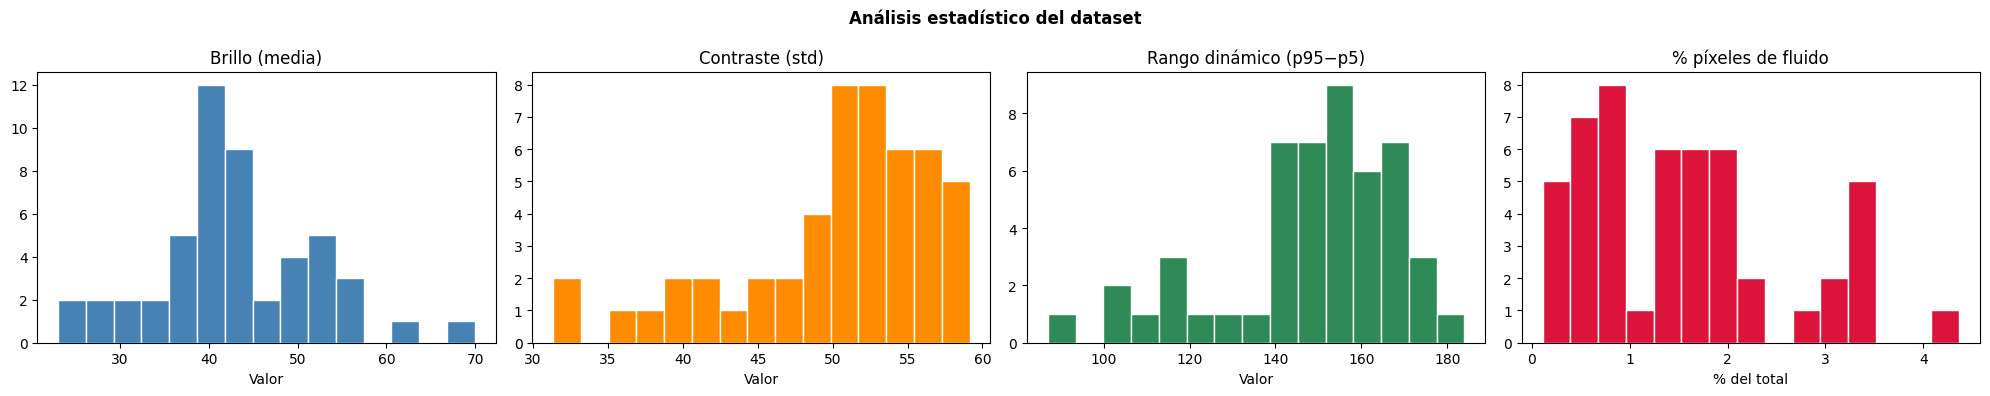

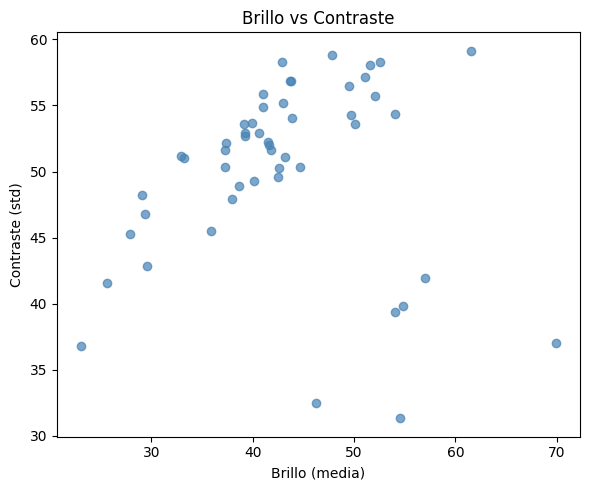

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Análisis estadístico del dataset', fontsize=12, fontweight='bold')

axes[0].hist(df_stats['brightness'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Brillo (media)')
axes[0].set_xlabel('Valor')

axes[1].hist(df_stats['contrast'], bins=15, color='darkorange', edgecolor='white')
axes[1].set_title('Contraste (std)')
axes[1].set_xlabel('Valor')

axes[2].hist(df_stats['dynamic_range'], bins=15, color='seagreen', edgecolor='white')
axes[2].set_title('Rango dinámico (p95−p5)')
axes[2].set_xlabel('Valor')

axes[3].hist(df_stats['fluid_ratio'], bins=15, color='crimson', edgecolor='white')
axes[3].set_title('% píxeles de fluido')
axes[3].set_xlabel('% del total')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(df_stats['brightness'], df_stats['contrast'], alpha=0.7, color='steelblue')
plt.xlabel('Brillo (media)')
plt.ylabel('Contraste (std)')
plt.title('Brillo vs Contraste')
plt.tight_layout()
plt.show()

In [7]:
b_mean = df_stats['brightness'].mean()
b_std  = df_stats['brightness'].std()
c_mean = df_stats['contrast'].mean()
c_std  = df_stats['contrast'].std()

BRIGHTNESS_FACTOR = round(float(b_std / b_mean), 2)
CONTRAST_FACTOR   = round(float(c_std / c_mean), 2)

print(f'Brillo    — media: {b_mean:.1f}  std: {b_std:.1f}  → brightness_factor: {BRIGHTNESS_FACTOR}')
print(f'Contraste — media: {c_mean:.1f}  std: {c_std:.1f}  → contrast_factor  : {CONTRAST_FACTOR}')
print(f'\nColorJitter(brightness={BRIGHTNESS_FACTOR}, contrast={CONTRAST_FACTOR})')
print(f'\nDesbalanceo de clases:')
print(f'  % fluido medio : {df_stats["fluid_ratio"].mean():.2f}%')
print(f'  % fluido mínimo: {df_stats["fluid_ratio"].min():.2f}%')
print(f'  % fluido máximo: {df_stats["fluid_ratio"].max():.2f}%')
print('\n→ Desbalanceo severo justifica el uso de Dice Loss.')

Brillo    — media: 43.0  std: 9.3  → brightness_factor: 0.22
Contraste — media: 50.2  std: 6.8  → contrast_factor  : 0.14

ColorJitter(brightness=0.22, contrast=0.14)

Desbalanceo de clases:
  % fluido medio : 1.54%
  % fluido mínimo: 0.11%
  % fluido máximo: 4.37%

→ Desbalanceo severo justifica el uso de Dice Loss.


## Sección 2 — Dataset y Split

Extendemos la clase `Dataset` de PyTorch para cargar las imágenes OCT y sus máscaras. El split es fijo con semilla y no cambia entre experimentos: **35 train / 5 val / 10 test**.

In [15]:
class OCTDataset(Dataset):

    def __init__(self, image_path, mask_path, rsize=(416, 624), transform=None):
        super().__init__()
        self.img_files = glob.glob(os.path.join(image_path, '*.jpg'))
        self.mask_files = []
        for img_path in self.img_files:
            self.mask_files.append(os.path.join(mask_path, os.path.basename(img_path)))
        self.rsize     = rsize
        self.transform = transform

    def __getitem__(self, index):
        img_path  = self.img_files[index]
        mask_path = self.mask_files[index]
        image = plt.imread(img_path)
        mask  = plt.imread(mask_path)
        if len(mask.shape) > 2:
            mask = mask[:, :, 0]
        if len(image.shape) > 2:
            image = image[:, :, 0]
        _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
        if self.transform is not None:
            seed = np.random.randint(2147483647)
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.transform(image)
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.transform(mask)
        else:
            t = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(self.rsize, interpolation=InterpolationMode.NEAREST),
                transforms.ToTensor()])
            image = t(image)
            mask  = t(mask)
        return image, mask

    def __len__(self):
        return len(self.img_files)

In [16]:
# Split fijo — no cambia entre experimentos
all_indices = list(range(50))
rng = random.Random(SEED)
rng.shuffle(all_indices)

train_idx = all_indices[:35]
val_idx   = all_indices[35:40]
test_idx  = all_indices[40:]

print(f'Train: {len(train_idx)} imágenes')
print(f'Val:   {len(val_idx)} imágenes')
print(f'Test:  {len(test_idx)} imágenes')


def make_loaders(train_ds, val_ds, test_ds, batch_size=BATCH_SIZE):
    train_loader = DataLoader(Subset(train_ds, train_idx), batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True,
                              persistent_workers=True)
    val_loader   = DataLoader(Subset(val_ds,   val_idx),   batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True,
                              persistent_workers=True)
    test_loader  = DataLoader(Subset(test_ds,  test_idx),  batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True,
                              persistent_workers=True)
    return train_loader, val_loader, test_loader

Train: 35 imágenes
Val:   5 imágenes
Test:  10 imágenes


In [17]:
simple_dataset = OCTDataset(IMG_DIR, MASK_DIR)
print(f'Dataset total: {len(simple_dataset)} imágenes')

nsamples = 4
for _ in range(nsamples):
    idx = np.random.randint(0, len(simple_dataset))
    im, mask = simple_dataset[idx]
    show(im.squeeze(), mask.squeeze(), title=f'Muestra {idx}')

Dataset total: 50 imágenes


RuntimeError: Numpy is not available

## Sección 3 — Arquitectura de red

UNet es una red convolucional encoder-decoder con skip connections diseñada para segmentación de imágenes biomédicas. Cada nivel del encoder aplica dos convoluciones 3×3 seguidas de ReLU (`double_conv`), con MaxPool2d entre niveles. El decoder recupera la resolución espacial con Upsample bilineal y concatena los skip connections del encoder para preservar los detalles finos de los bordes del fluido.

In [18]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
    )


class UNet(nn.Module):

    def __init__(self, input_channels, n_class):
        super().__init__()
        self.dconv_down1 = double_conv(input_channels, 64)
        self.dconv_down2 = double_conv(64, 128)
        self.dconv_down3 = double_conv(128, 256)
        self.dconv_down4 = double_conv(256, 512)
        self.maxpool  = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dconv_up3 = double_conv(256 + 512, 256)
        self.dconv_up2 = double_conv(128 + 256, 128)
        self.dconv_up1 = double_conv(128 + 64, 64)
        self.conv_last = nn.Conv2d(64, n_class, 1)

    def forward(self, x):
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)
        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)
        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)
        x = self.dconv_down4(x)
        x = self.upsample(x)
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)
        x = self.upsample(x)
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        return self.conv_last(x)

## Sección 4 — Baseline

### 4.1 Funciones auxiliares reutilizables

Todas las funciones de entrenamiento, evaluación y visualización se definen aquí una única vez y se reutilizan en todos los experimentos.

In [ ]:
from torchmetrics.classification import (
    BinaryJaccardIndex, BinaryF1Score,
    BinaryPrecision, BinaryRecall, BinaryAccuracy
)

def make_metrics(device):
    return {
        'iou':       BinaryJaccardIndex().to(device),
        'dice':      BinaryF1Score().to(device),
        'precision': BinaryPrecision().to(device),
        'recall':    BinaryRecall().to(device),
        'accuracy':  BinaryAccuracy().to(device),
    }

def compute_metrics(metrics_dict):
    result = {k: m.compute().item() for k, m in metrics_dict.items()}
    for m in metrics_dict.values():
        m.reset()
    return result

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    metrics = make_metrics(device)

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(images)

        with torch.no_grad():
            preds = get_segmentation_masks(outputs).int()
            for m in metrics.values():
                m.update(preds, masks.int())

    return total_loss / len(loader.dataset), compute_metrics(metrics)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    metrics = make_metrics(device)

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item() * len(images)
            preds = get_segmentation_masks(outputs).int()
            for m in metrics.values():
                m.update(preds, masks.int())

    return total_loss / len(loader.dataset), compute_metrics(metrics)



In [14]:
def train_model(model, train_loader, val_loader, criterion,
                max_epochs=100, lr=1e-3,
                checkpoint_path='model.pth', device=DEVICE):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5)

    history = {k: [] for k in
               ['train_loss', 'val_loss', 'train_iou', 'val_iou',
                'train_dice', 'val_dice']}
    best_val_loss = float('inf')

    for epoch in range(max_epochs):
        train_loss, train_m = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_m   = eval_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_m['iou'])
        history['val_iou'].append(val_m['iou'])
        history['train_dice'].append(train_m['dice'])
        history['val_dice'].append(val_m['dice'])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_path)

        if (epoch + 1) % 10 == 0:
            print(f'Epoca {epoch+1:3d}/{max_epochs} | '
                  f'Train Loss: {train_loss:.4f}  IoU: {train_m["iou"]:.4f}  '
                  f'Dice: {train_m["dice"]:.4f} | '
                  f'Val Loss: {val_loss:.4f}  IoU: {val_m["iou"]:.4f}  '
                  f'Dice: {val_m["dice"]:.4f}')

    model.load_state_dict(torch.load(checkpoint_path, map_location=device,
                                     weights_only=True))
    print(f"\nEntrenamiento completado. Mejor modelo guardado en '{checkpoint_path}'")
    return history

In [ ]:
def evaluate_model(model, loader, device, experiment_name='Modelo'):
    model.eval()
    metrics = make_metrics(device)

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = get_segmentation_masks(model(images)).int()
            for m in metrics.values():
                m.update(preds, masks.int())

    results = compute_metrics(metrics)
    print(f'\n=== {experiment_name} — Resultados en Test ===')
    for k, v in results.items():
        print(f'  {k.capitalize():10s}: {v:.4f}')

    # visualización igual que antes
    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = get_segmentation_masks(model(images))
            for i in range(len(images)):
                if shown >= 3:
                    break
                show_result(images[i].cpu().squeeze(), masks[i].cpu().squeeze(),
                            preds[i].cpu().squeeze(),
                            title=f'{experiment_name} — Muestra {shown + 1}')
                shown += 1
            if shown >= 3:
                break
    return results


def plot_training_history(history, experiment_name='Modelo'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'{experiment_name} \u2014 Curvas de entrenamiento',
                 fontsize=12, fontweight='bold')

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('\u00c9poca')
    axes[0].legend()

    axes[1].plot(epochs, history['train_iou'], label='Train')
    axes[1].plot(epochs, history['val_iou'],   label='Val')
    axes[1].set_title('IoU')
    axes[1].set_xlabel('\u00c9poca')
    axes[1].legend()

    axes[2].plot(epochs, history['train_dice'], label='Train')
    axes[2].plot(epochs, history['val_dice'],   label='Val')
    axes[2].set_title('Dice')
    axes[2].set_xlabel('\u00c9poca')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### 4.2 Entrenamiento del baseline

**Configuración**: UNet desde cero, `BCEWithLogitsLoss`, sin augmentation, sin CLAHE.

Epoca  10/100 | Train Loss: 0.0753  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.0999  IoU: 0.0000  Dice: 0.0000
Epoca  20/100 | Train Loss: 0.0686  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.0913  IoU: 0.0000  Dice: 0.0000
Epoca  30/100 | Train Loss: 0.0740  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.1011  IoU: 0.0000  Dice: 0.0000
Epoca  40/100 | Train Loss: 0.0621  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.0852  IoU: 0.0000  Dice: 0.0000
Epoca  50/100 | Train Loss: 0.0303  IoU: 0.4548  Dice: 0.6253 | Val Loss: 0.0767  IoU: 0.3101  Dice: 0.4734
Epoca  60/100 | Train Loss: 0.0245  IoU: 0.5428  Dice: 0.7036 | Val Loss: 0.0695  IoU: 0.3521  Dice: 0.5208
Epoca  70/100 | Train Loss: 0.0205  IoU: 0.5830  Dice: 0.7366 | Val Loss: 0.0696  IoU: 0.3758  Dice: 0.5463
Epoca  80/100 | Train Loss: 0.0204  IoU: 0.5935  Dice: 0.7449 | Val Loss: 0.0841  IoU: 0.3384  Dice: 0.5057
Epoca  90/100 | Train Loss: 0.0150  IoU: 0.6812  Dice: 0.8104 | Val Loss: 0.0935  IoU: 0.3711  Dice: 0.5413
Epoca 100/100 | Train Loss: 

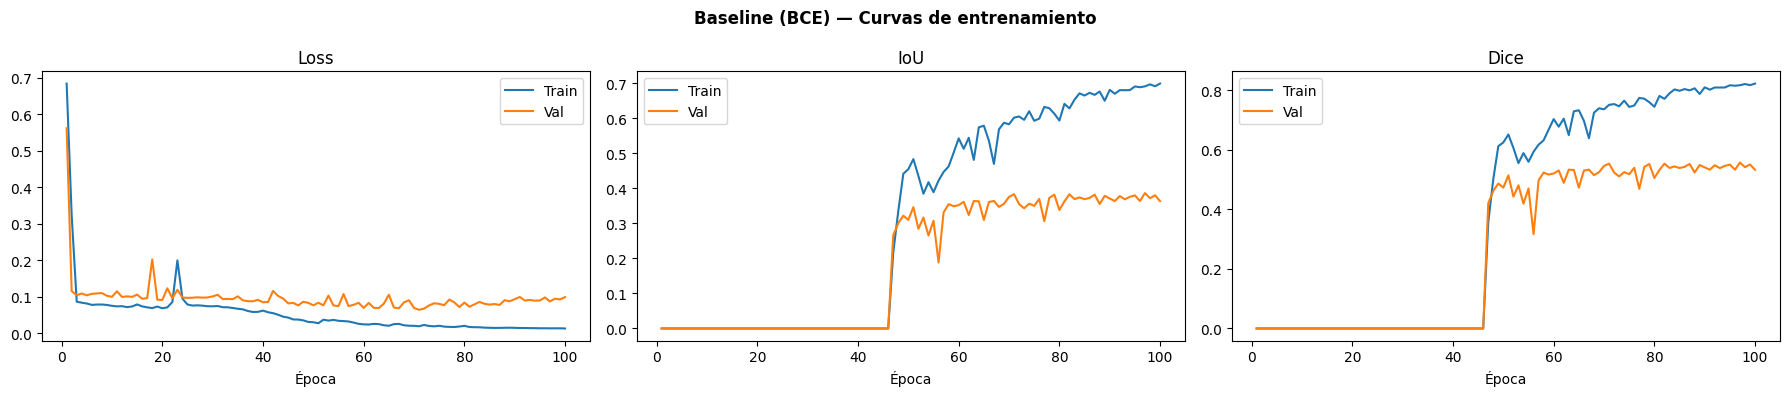


=== Baseline (BCE) — Resultados en Test ===
  Iou       : 0.6134
  Dice      : 0.7603
  Precision : 0.7931
  Recall    : 0.7302
  Accuracy  : 0.9952


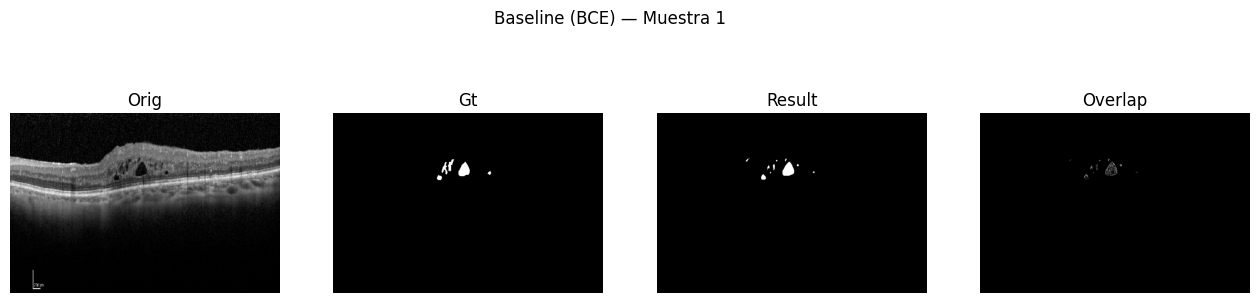

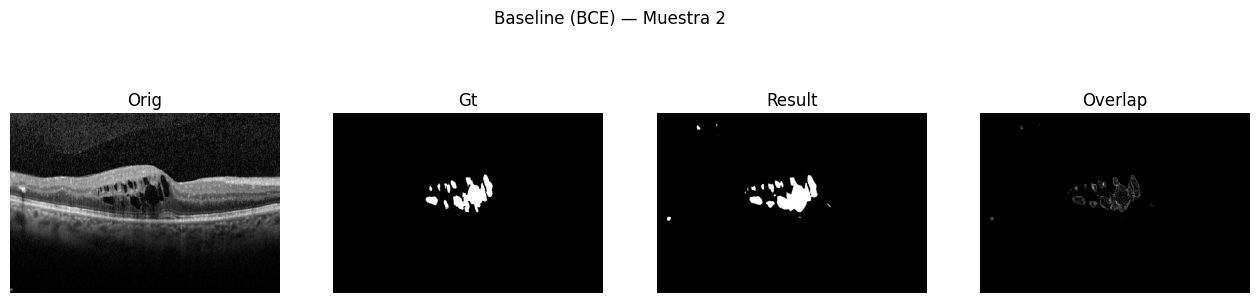

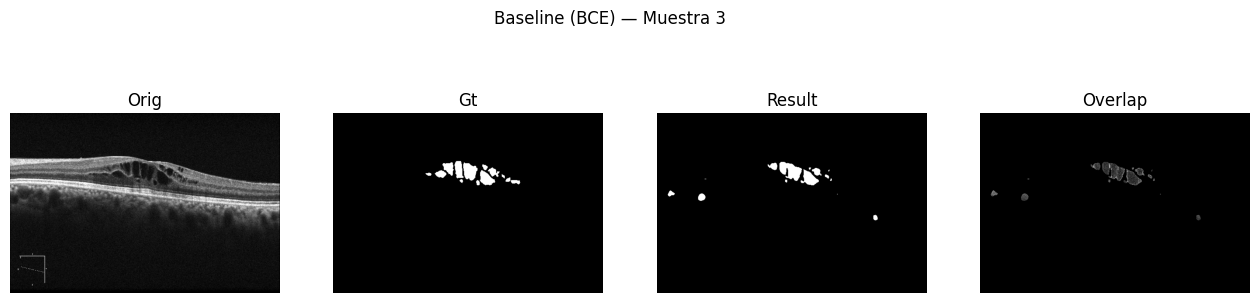

In [16]:
base_ds = OCTDataset(IMG_DIR, MASK_DIR)
train_loader_base, val_loader_base, test_loader_base = make_loaders(base_ds, base_ds, base_ds)

model_base    = UNet(input_channels=1, n_class=1).to(DEVICE)
criterion_bce = nn.BCEWithLogitsLoss()

history_base = train_model(
    model_base, train_loader_base, val_loader_base,
    criterion=criterion_bce,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/baseline.pth',
    device=DEVICE
)

plot_training_history(history_base, experiment_name='Baseline (BCE)')
baseline_metrics = evaluate_model(model_base, test_loader_base, DEVICE,
                                  experiment_name='Baseline (BCE)')

## Sección 5 — Experimento/Mejora 1: Dice Loss

**Motivación**: `BCEWithLogitsLoss` trata todos los píxeles por igual. Con desbalanceo severo (el fluido ocupa una pequeña fracción de los píxeles), la red aprende a predecir todo negro obteniendo alta accuracy pero IoU y Dice nulos. Dice Loss optimiza directamente el coeficiente Dice, que es invariante al desbalanceo de clases.

In [17]:
def dice_loss(outputs, targets, smooth=1.0):
    probs   = torch.sigmoid(outputs).view(-1)
    targets = targets.view(-1)
    intersection = (probs * targets).sum()
    return 1 - (2 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)

Epoca  10/100 | Train Loss: 0.9685  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  20/100 | Train Loss: 0.9684  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  30/100 | Train Loss: 0.9685  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  40/100 | Train Loss: 0.9684  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  50/100 | Train Loss: 0.9684  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  60/100 | Train Loss: 0.9685  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  70/100 | Train Loss: 0.9685  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  80/100 | Train Loss: 0.9685  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca  90/100 | Train Loss: 0.9684  IoU: 0.0161  Dice: 0.0316 | Val Loss: 0.9597  IoU: 0.0206  Dice: 0.0403
Epoca 100/100 | Train Loss: 

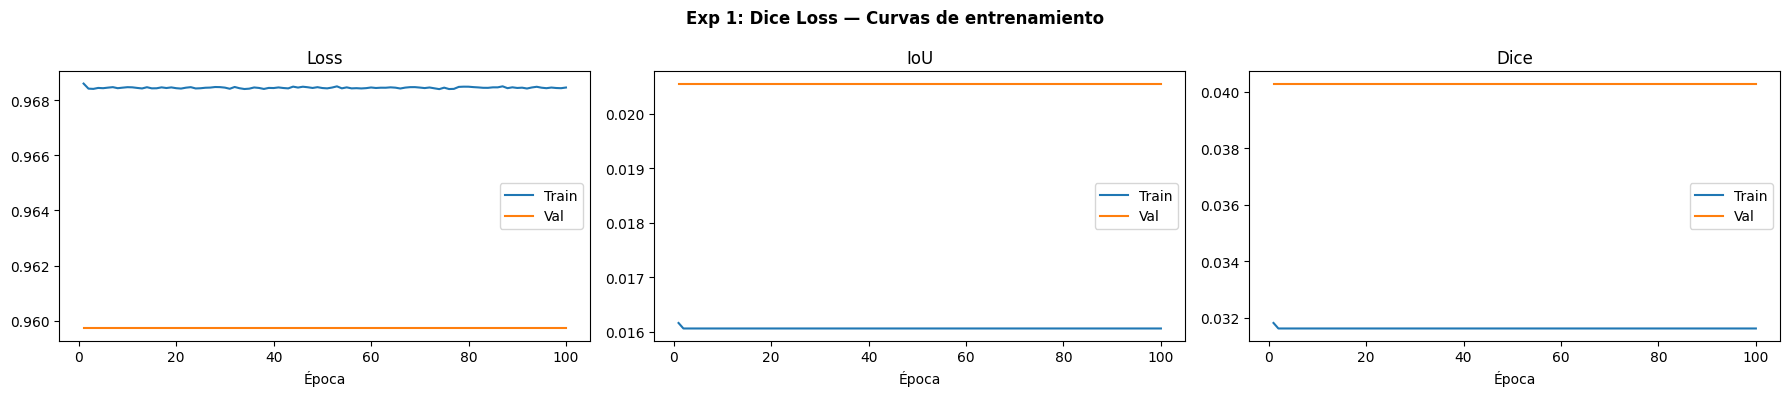


=== Exp 1: Dice Loss — Resultados en Test ===
  Iou       : 0.0105
  Dice      : 0.0208
  Precision : 0.0105
  Recall    : 1.0000
  Accuracy  : 0.0105


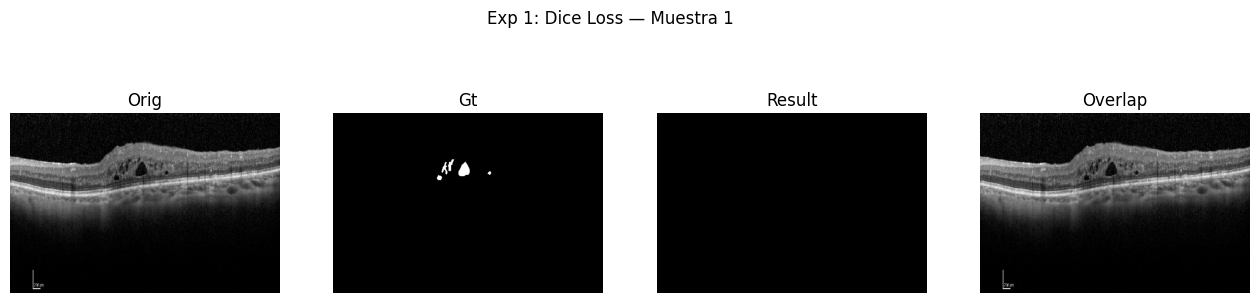

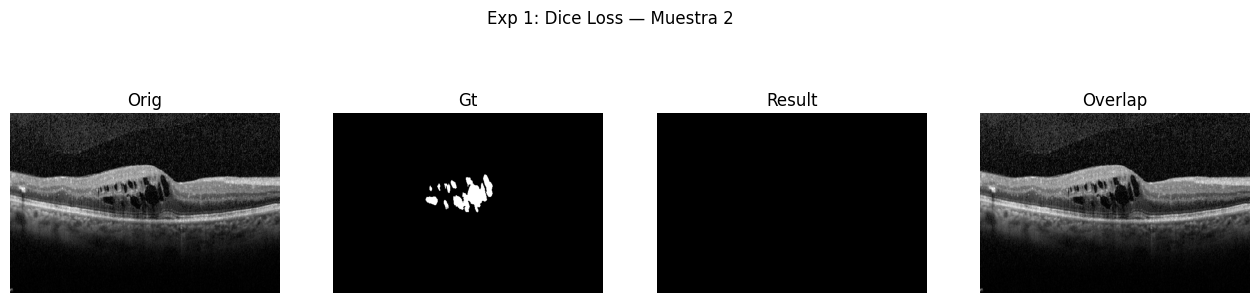

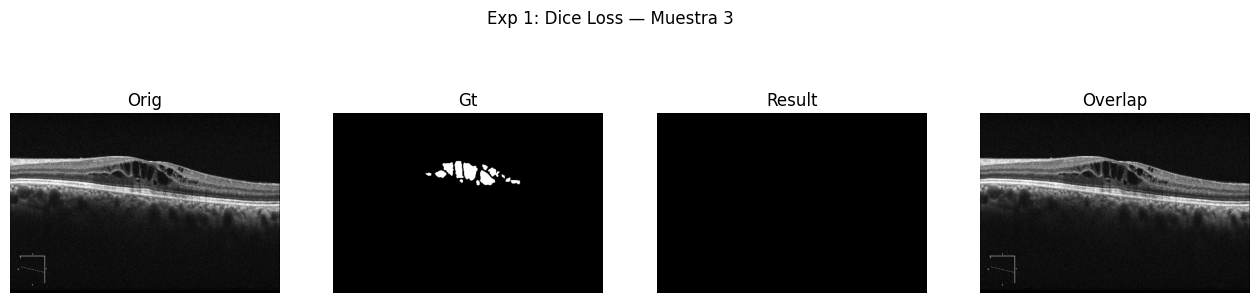

In [18]:
model_dice = UNet(input_channels=1, n_class=1).to(DEVICE)

history_dice = train_model(
    model_dice, train_loader_base, val_loader_base,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp1_dice.pth',
    device=DEVICE
)

plot_training_history(history_dice, experiment_name='Exp 1: Dice Loss')
exp1_metrics = evaluate_model(model_dice, test_loader_base, DEVICE,
                              experiment_name='Exp 1: Dice Loss')

## Sección 6 — Experimento/Mejora 2: CLAHE

**Motivación**: CLAHE (Contrast Limited Adaptive Histogram Equalization) es el estándar en preprocesado de imágenes OCT. Mejora el contraste local sin saturar, haciendo los bordes del fluido más visibles. A diferencia del histograma global, opera en bloques locales preservando la estructura de las capas retinianas.

Primero comparamos visualmente distintos valores de `clipLimit` para seleccionar el óptimo.

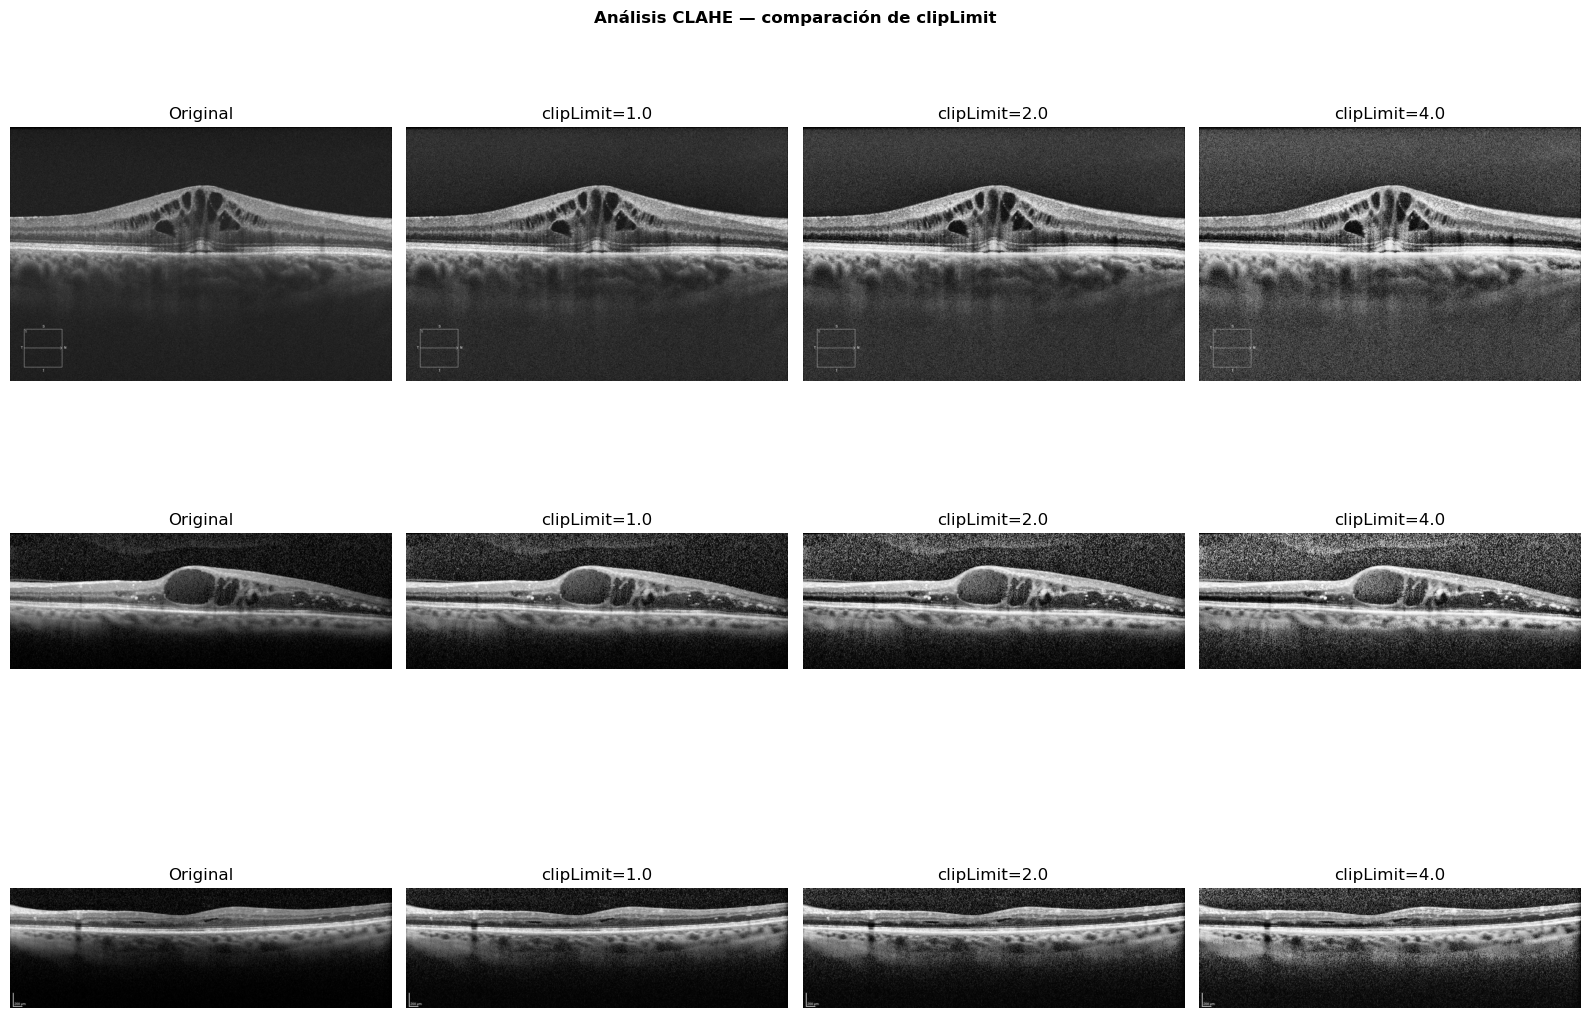

clipLimit=1.0  separabilidad media: 0.2963
clipLimit=2.0  separabilidad media: 0.3632
clipLimit=4.0  separabilidad media: 0.4536


In [19]:
sample_paths = [
    f'{route}/OCT-dataset/images/sample_01.jpg',
    f'{route}/OCT-dataset/images/sample_10.jpg',
    f'{route}/OCT-dataset/images/sample_25.jpg',
]
clip_limits = [1.0, 2.0, 4.0]

fig, axes = plt.subplots(len(sample_paths), len(clip_limits) + 1,
                          figsize=(16, 4 * len(sample_paths)))
fig.suptitle('Análisis CLAHE \u2014 comparación de clipLimit', fontsize=12, fontweight='bold')

for row, path in enumerate(sample_paths):
    img = plt.imread(path)
    if len(img.shape) > 2:
        img = img[:, :, 0]
    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')
    for col, cl in enumerate(clip_limits):
        proc    = cv2.createCLAHE(clipLimit=cl, tileGridSize=(8, 8))
        enhanced = proc.apply(img)
        axes[row, col + 1].imshow(enhanced, cmap='gray')
        axes[row, col + 1].set_title(f'clipLimit={cl}')
        axes[row, col + 1].axis('off')

plt.tight_layout()
plt.show()

results = {cl: [] for cl in clip_limits}

for img_path in glob.glob(os.path.join(IMG_DIR, '*.jpg')):
    img  = plt.imread(img_path)
    mask = plt.imread(os.path.join(MASK_DIR, os.path.basename(img_path)))
    if len(img.shape)  > 2: img  = img[:, :, 0]
    if len(mask.shape) > 2: mask = mask[:, :, 0]
    _, mask_bin = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)

    if mask_bin.sum() == 0:
        continue

    for cl in clip_limits:
        enhanced = cv2.createCLAHE(clipLimit=cl, tileGridSize=(8,8)).apply(img)
        fluid_pixels  = enhanced[mask_bin > 0]
        fondo_pixels  = enhanced[mask_bin == 0]
        sep = abs(fluid_pixels.mean() - fondo_pixels.mean()) / (fondo_pixels.std() + 1e-8)
        results[cl].append(sep)

for cl in clip_limits:
    print(f'clipLimit={cl:.1f}  separabilidad media: {np.mean(results[cl]):.4f}')

In [ ]:
CLAHE_CLIP_LIMIT = 2.0  # seleccionado tras análisis visual
print(f'clipLimit seleccionado: {CLAHE_CLIP_LIMIT}')

In [20]:
class EnhancedOCTDataset(OCTDataset):
    """OCTDataset con CLAHE opcional y ColorJitter sobre la imagen."""

    def __init__(self, image_path, mask_path, rsize=(416, 624), transform=None,
                 clip_limit=None, brightness=0.0, contrast=0.0):
        super().__init__(image_path, mask_path, rsize, transform)
        self.clahe = (cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
                      if clip_limit else None)
        cj_active = brightness > 0 or contrast > 0
        self.color_jitter = (transforms.ColorJitter(brightness=brightness,
                                                    contrast=contrast)
                             if cj_active else None)

    def __getitem__(self, index):
        img_path  = self.img_files[index]
        mask_path = self.mask_files[index]
        image = plt.imread(img_path)
        mask  = plt.imread(mask_path)
        if len(mask.shape) > 2:
            mask = mask[:, :, 0]
        if len(image.shape) > 2:
            image = image[:, :, 0]
        _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)

        if self.clahe is not None:
            image = self.clahe.apply(image)

        if self.transform is not None:
            seed = np.random.randint(2147483647)
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.transform(image)
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.transform(mask)
        else:
            t = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(self.rsize, interpolation=InterpolationMode.NEAREST),
                transforms.ToTensor()])
            image = t(image)
            mask  = t(mask)

        # ColorJitter solo sobre la imagen (tensor [0,1]), no sobre la máscara
        if self.color_jitter is not None:
            image = self.color_jitter(image)

        return image, mask

Epoca  10/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  20/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  30/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  40/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  50/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  60/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  70/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  80/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca  90/100 | Train Loss: 0.9999  IoU: 0.0000  Dice: 0.0000 | Val Loss: 0.9999  IoU: 0.0000  Dice: 0.0000
Epoca 100/100 | Train Loss: 

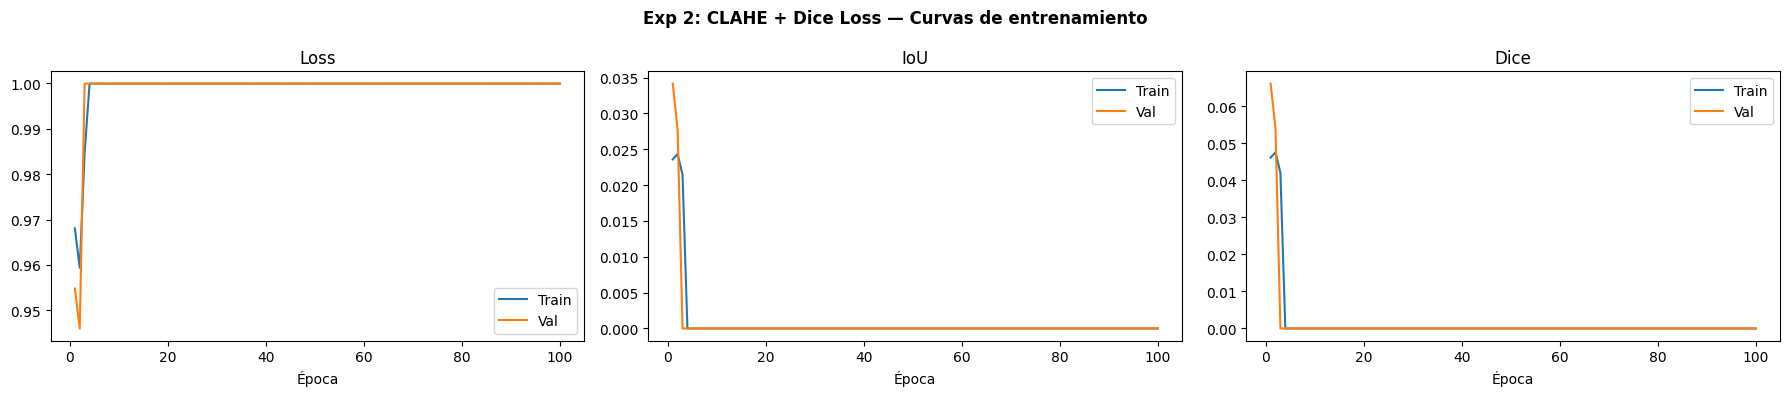


=== Exp 2: CLAHE + Dice Loss — Resultados en Test ===
  Iou       : 0.0136
  Dice      : 0.0269
  Precision : 0.0136
  Recall    : 1.0000
  Accuracy  : 0.2400


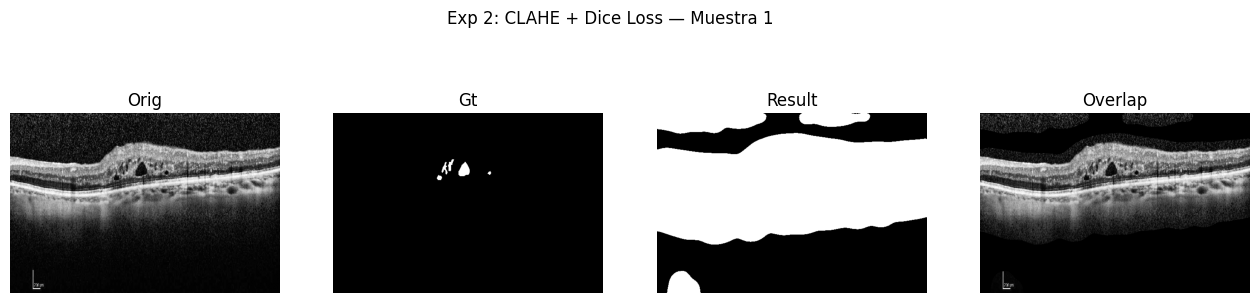

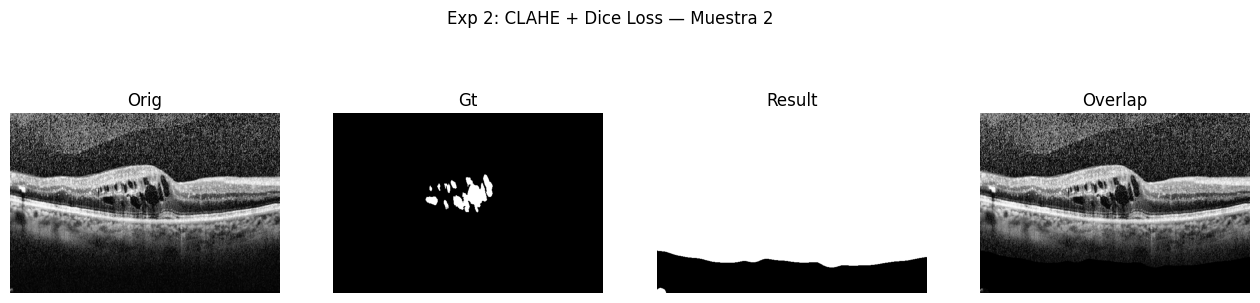

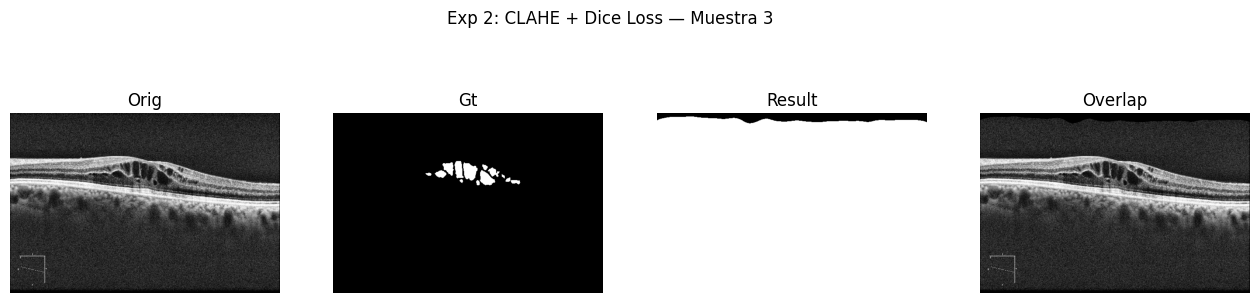

In [21]:
clahe_ds = EnhancedOCTDataset(IMG_DIR, MASK_DIR, clip_limit=CLAHE_CLIP_LIMIT)
train_loader_clahe, val_loader_clahe, test_loader_clahe = make_loaders(
    clahe_ds, clahe_ds, clahe_ds)

model_clahe = UNet(input_channels=1, n_class=1).to(DEVICE)

history_clahe = train_model(
    model_clahe, train_loader_clahe, val_loader_clahe,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp2_clahe.pth',
    device=DEVICE
)

plot_training_history(history_clahe, experiment_name='Exp 2: CLAHE + Dice Loss')
exp2_metrics = evaluate_model(model_clahe, test_loader_clahe, DEVICE,
                              experiment_name='Exp 2: CLAHE + Dice Loss')

## Sección 7 — Experimento/Mejora 3: Ajuste de hiperparámetros

Una vez tenemos el loss correcto y las img normalizadas con clahe hacemos esto

In [ ]:
print("hacer esto")

## Sección 8 — Experimento/Mejora 4: Data Augmentation

**Motivación**: Con 35 imágenes de entrenamiento el modelo sobreajusta sin augmentation. Las transformaciones se diseñan respetando la validez anatómica de las imágenes OCT:
- **Flip horizontal**: la fóvea puede aparecer a izquierda o derecha según el corte.
- **Rotación ±10°**: simula pequeñas variaciones de posicionamiento del paciente.
- **ColorJitter**: los factores se derivan del análisis estadístico (Sección 1) y simulan variaciones entre escáneres OCT. Se aplica solo a la imagen, no a la máscara.

Las transformaciones geométricas se aplican de forma consistente a imagen y máscara mediante el mecanismo de semilla sincronizada de `OCTDataset`. El augmentation se aplica **solo al conjunto de entrenamiento**.

In [22]:
geo_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(RSIZE, interpolation=InterpolationMode.NEAREST),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
])

# Train: CLAHE + transformaciones geométricas + ColorJitter
aug_ds_train = EnhancedOCTDataset(
    IMG_DIR, MASK_DIR,
    transform=geo_transform,
    clip_limit=CLAHE_CLIP_LIMIT,
    brightness=BRIGHTNESS_FACTOR,
    contrast=CONTRAST_FACTOR
)
# Val / Test: solo CLAHE, sin augmentation
aug_ds_valtest = EnhancedOCTDataset(IMG_DIR, MASK_DIR, clip_limit=CLAHE_CLIP_LIMIT)

train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(
    aug_ds_train, aug_ds_valtest, aug_ds_valtest)

Epoca  10/100 | Train Loss: 0.7450  IoU: 0.1299  Dice: 0.2299 | Val Loss: 0.5645  IoU: 0.3063  Dice: 0.4689
Epoca  20/100 | Train Loss: 0.3534  IoU: 0.4622  Dice: 0.6322 | Val Loss: 0.3814  IoU: 0.4562  Dice: 0.6266
Epoca  30/100 | Train Loss: 0.4164  IoU: 0.4478  Dice: 0.6186 | Val Loss: 0.4048  IoU: 0.4310  Dice: 0.6024
Epoca  40/100 | Train Loss: 0.3479  IoU: 0.4873  Dice: 0.6553 | Val Loss: 0.2843  IoU: 0.5567  Dice: 0.7152
Epoca  50/100 | Train Loss: 0.2270  IoU: 0.6244  Dice: 0.7688 | Val Loss: 0.3047  IoU: 0.5389  Dice: 0.7003
Epoca  60/100 | Train Loss: 0.2240  IoU: 0.6449  Dice: 0.7841 | Val Loss: 0.2969  IoU: 0.5474  Dice: 0.7075
Epoca  70/100 | Train Loss: 0.2301  IoU: 0.6474  Dice: 0.7860 | Val Loss: 0.2876  IoU: 0.5572  Dice: 0.7157
Epoca  80/100 | Train Loss: 0.1422  IoU: 0.7535  Dice: 0.8594 | Val Loss: 0.2846  IoU: 0.5595  Dice: 0.7176
Epoca  90/100 | Train Loss: 0.1485  IoU: 0.7516  Dice: 0.8582 | Val Loss: 0.2556  IoU: 0.5953  Dice: 0.7463
Epoca 100/100 | Train Loss: 

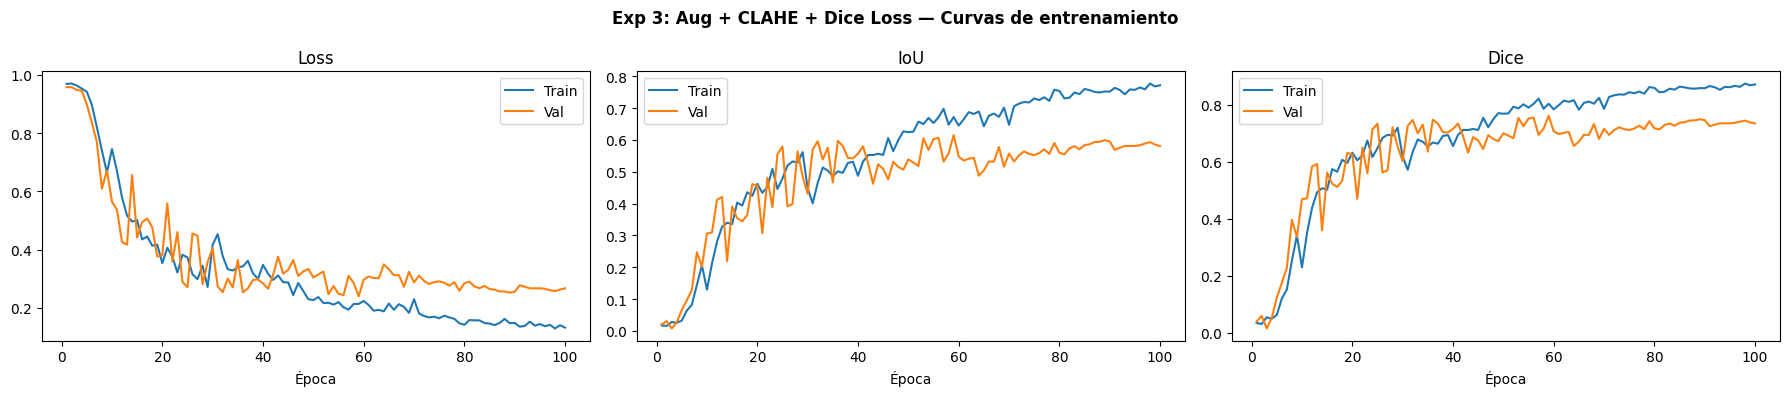


=== Exp 3: Aug + CLAHE + Dice Loss — Resultados en Test ===
  Iou       : 0.6753
  Dice      : 0.8062
  Precision : 0.7748
  Recall    : 0.8401
  Accuracy  : 0.9958


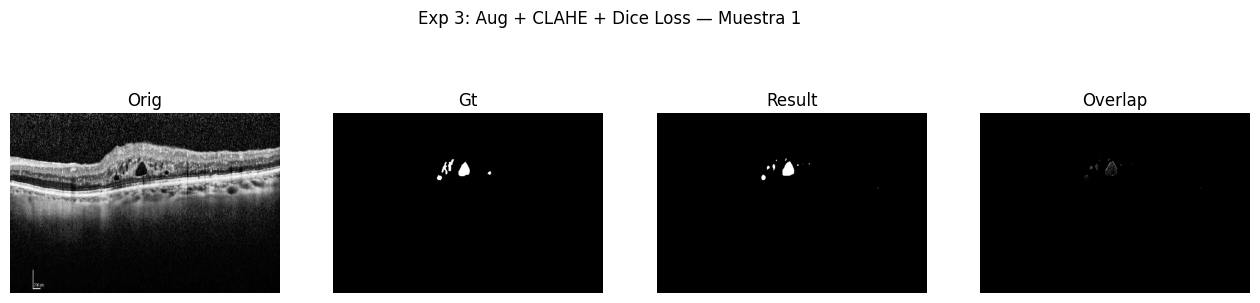

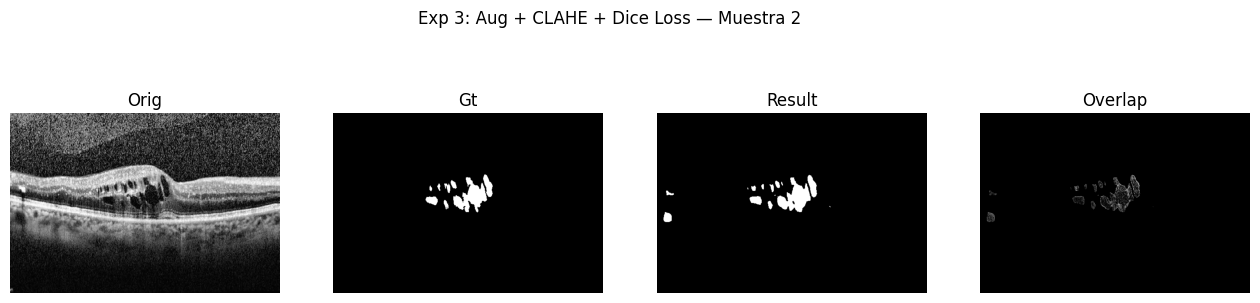

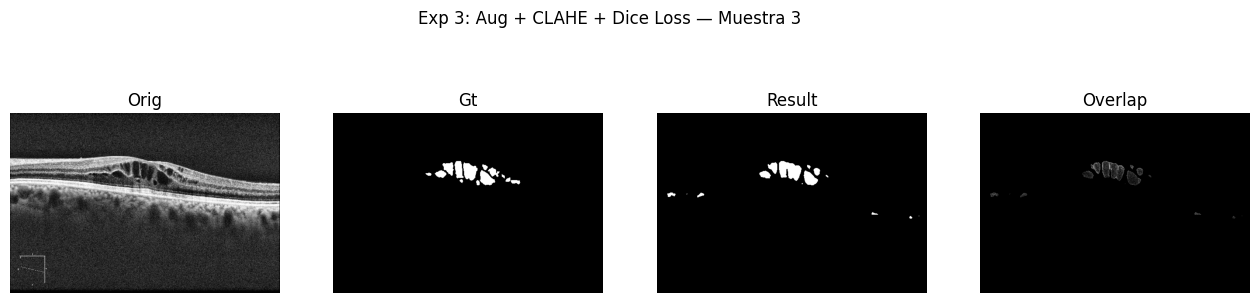

In [23]:
model_aug = UNet(input_channels=1, n_class=1).to(DEVICE)

history_aug = train_model(
    model_aug, train_loader_aug, val_loader_aug,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-3,
    checkpoint_path=f'{route}/models/exp3_augmentation.pth',
    device=DEVICE
)

plot_training_history(history_aug, experiment_name='Exp 3: Aug + CLAHE + Dice Loss')
exp3_metrics = evaluate_model(model_aug, test_loader_aug, DEVICE,
                              experiment_name='Exp 3: Aug + CLAHE + Dice Loss')

## Sección 9 — Experimento/Mejora 5: Encoder preentrenado (Transfer Learning)

**Motivación**: Con 35 imágenes de entrenamiento, aprender un encoder desde cero es un handicap significativo. Un encoder preentrenado en ImageNet ya dispone de detectores de bordes, texturas y estructuras jerárquicas que son directamente útiles para delimitar el fluido en OCT. Se usa ResNet18 como encoder por ser el más ligero, reduciendo el riesgo de sobreajuste con un dataset pequeño. Se usa un learning rate menor (1e-4) para no destruir los pesos preentrenados.

In [24]:
!pip install segmentation-models-pytorch -q
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoca  10/100 | Train Loss: 0.8119  IoU: 0.4781  Dice: 0.6469 | Val Loss: 0.7651  IoU: 0.4294  Dice: 0.6008
Epoca  20/100 | Train Loss: 0.6667  IoU: 0.6788  Dice: 0.8087 | Val Loss: 0.6316  IoU: 0.6123  Dice: 0.7595
Epoca  30/100 | Train Loss: 0.5074  IoU: 0.7716  Dice: 0.8711 | Val Loss: 0.4623  IoU: 0.7020  Dice: 0.8249
Epoca  40/100 | Train Loss: 0.3602  IoU: 0.8283  Dice: 0.9061 | Val Loss: 0.3359  IoU: 0.7140  Dice: 0.8332
Epoca  50/100 | Train Loss: 0.2385  IoU: 0.8592  Dice: 0.9243 | Val Loss: 0.2699  IoU: 0.7286  Dice: 0.8430
Epoca  60/100 | Train Loss: 0.1938  IoU: 0.8761  Dice: 0.9339 | Val Loss: 0.2219  IoU: 0.7402  Dice: 0.8507
Epoca  70/100 | Train Loss: 0.1387  IoU: 0.8819  Dice: 0.9373 | Val Loss: 0.1948  IoU: 0.7466  Dice: 0.8549
Epoca  80/100 | Train Loss: 0.1250  IoU: 0.8935  Dice: 0.9438 | Val Loss: 0.1725  IoU: 0.7612  Dice: 0.8644
Epoca  90/100 | Train Loss: 0.1024  IoU: 0.8931  Dice: 0.9435 | Val Loss: 0.1707  IoU: 0.7510  Dice: 0.8578
Epoca 100/100 | Train Loss: 

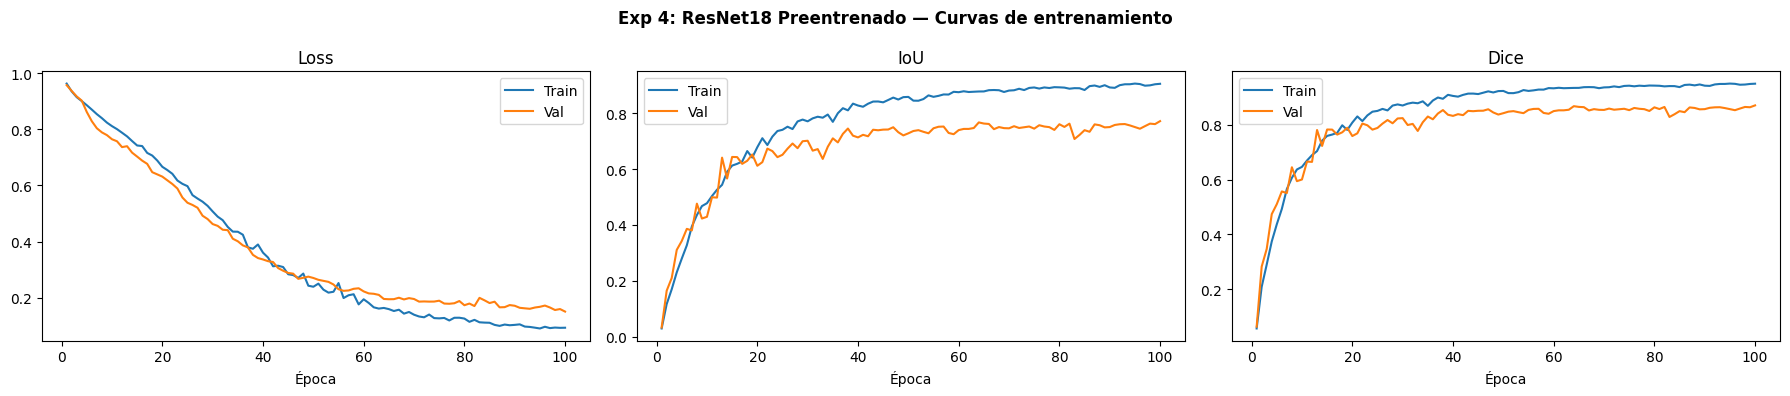


=== Exp 4: ResNet18 Preentrenado — Resultados en Test ===
  Iou       : 0.7274
  Dice      : 0.8422
  Precision : 0.8514
  Recall    : 0.8333
  Accuracy  : 0.9967


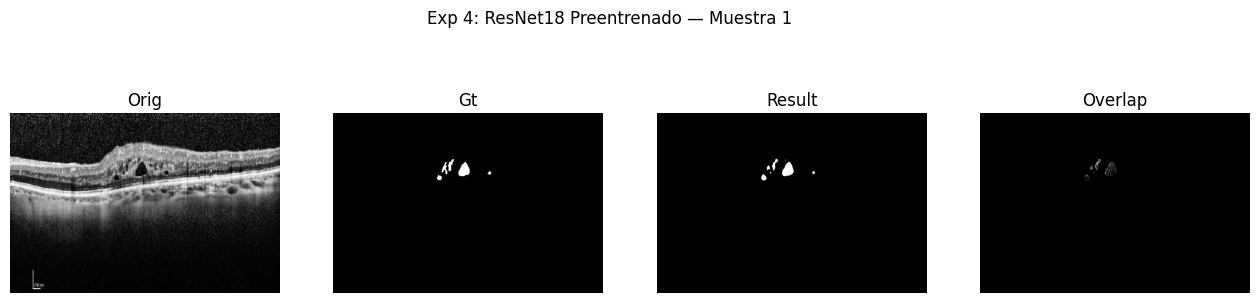

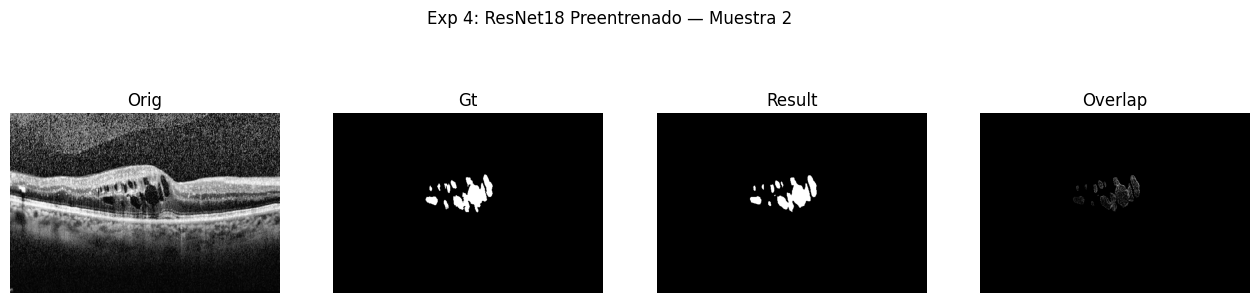

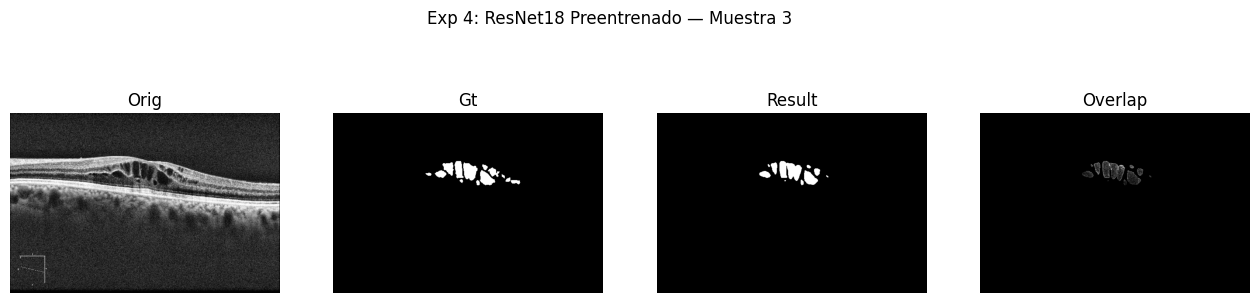

In [25]:
model_pretrained = smp.Unet(
    encoder_name='resnet18',
    encoder_weights='imagenet',
    in_channels=1,
    classes=1,
).to(DEVICE)

history_pretrained = train_model(
    model_pretrained, train_loader_aug, val_loader_aug,
    criterion=dice_loss,
    max_epochs=100,
    lr=1e-4,
    checkpoint_path=f'{route}/models/exp4_pretrained.pth',
    device=DEVICE
)

plot_training_history(history_pretrained, experiment_name='Exp 4: ResNet18 Preentrenado')
exp4_metrics = evaluate_model(model_pretrained, test_loader_aug, DEVICE,
                              experiment_name='Exp 4: ResNet18 Preentrenado')

## Sección 10 — Tabla comparativa de experimentos


=== Tabla comparativa de experimentos ===

                          IoU    Dice  Precision  Recall  Accuracy
Baseline (BCE)         0.6134  0.7603     0.7931  0.7302    0.9952
Exp 1: Dice Loss       0.0105  0.0208     0.0105  1.0000    0.0105
Exp 2: + CLAHE         0.0136  0.0269     0.0136  1.0000    0.2400
Exp 3: + Augmentation  0.6753  0.8062     0.7748  0.8401    0.9958
Exp 4: + Pretrained    0.7274  0.8422     0.8514  0.8333    0.9967


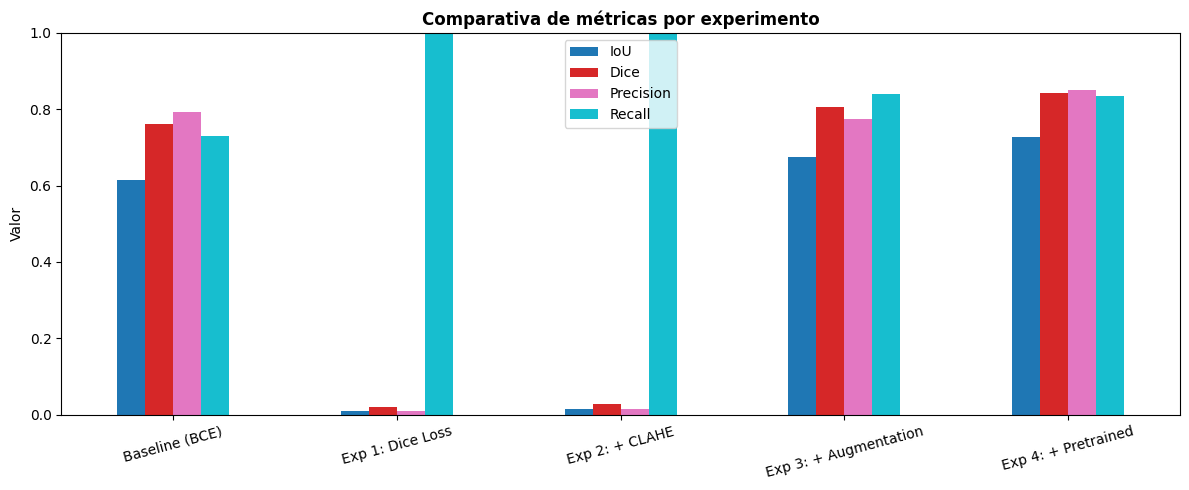

In [26]:
all_results = {
    'Baseline (BCE)':        baseline_metrics,
    'Exp 1: Dice Loss':      exp1_metrics,
    'Exp 2: + CLAHE':        exp2_metrics,
    'Exp 3: + Augmentation': exp3_metrics,
    'Exp 4: + Pretrained':   exp4_metrics,
}

df_results = pd.DataFrame(all_results).T
df_results.columns = ['IoU', 'Dice', 'Precision', 'Recall', 'Accuracy']
df_results = df_results.round(4)

print('\n=== Tabla comparativa de experimentos ===\n')
print(df_results.to_string())

# Visualización como gráfico de barras
df_results[['IoU', 'Dice', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(12, 5), rot=15, colormap='tab10')
plt.title('Comparativa de métricas por experimento', fontsize=12, fontweight='bold')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()